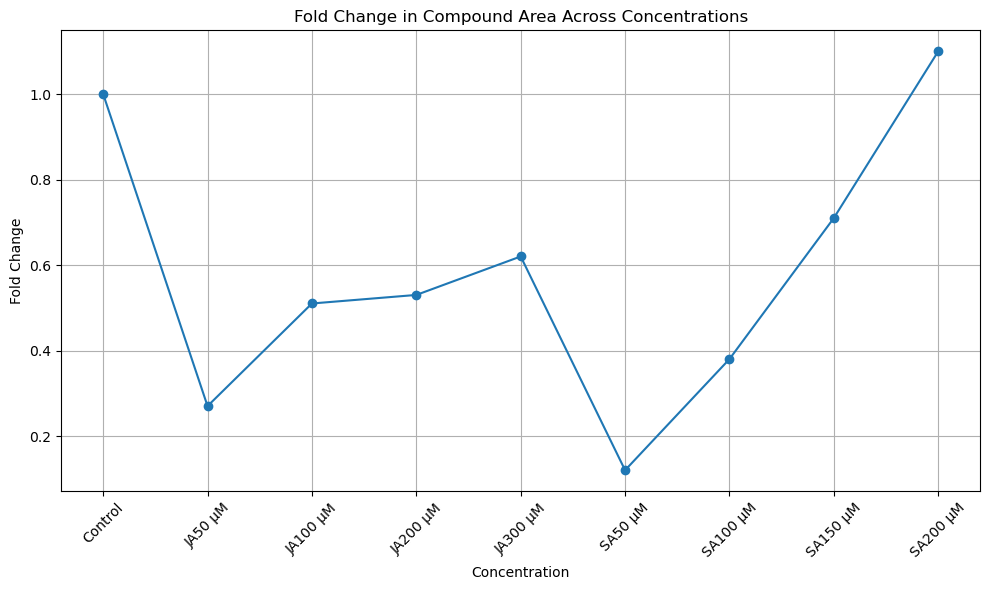

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the DataFrame based on the given data
data = {
    "Concentration": ["Control", "JA50 µM", "JA100 µM", "JA200 µM", "JA300 µM", "SA50 µM", "SA100 µM", "SA150 µM", "SA200 µM"],
    "Area": [592940, 161972, 303490, 316445, 370505, 68564, 224140, 420290, 651757],
    "Fold Change": [1, 0.27, 0.51, 0.53, 0.62, 0.12, 0.38, 0.71, 1.10]
}

df = pd.DataFrame(data)

# Plotting the fold change for each concentration
plt.figure(figsize=(10, 6))
plt.plot(df["Concentration"], df["Fold Change"], marker='o')
plt.title("Fold Change in Compound Area Across Concentrations")
plt.xlabel("Concentration")
plt.ylabel("Fold Change")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


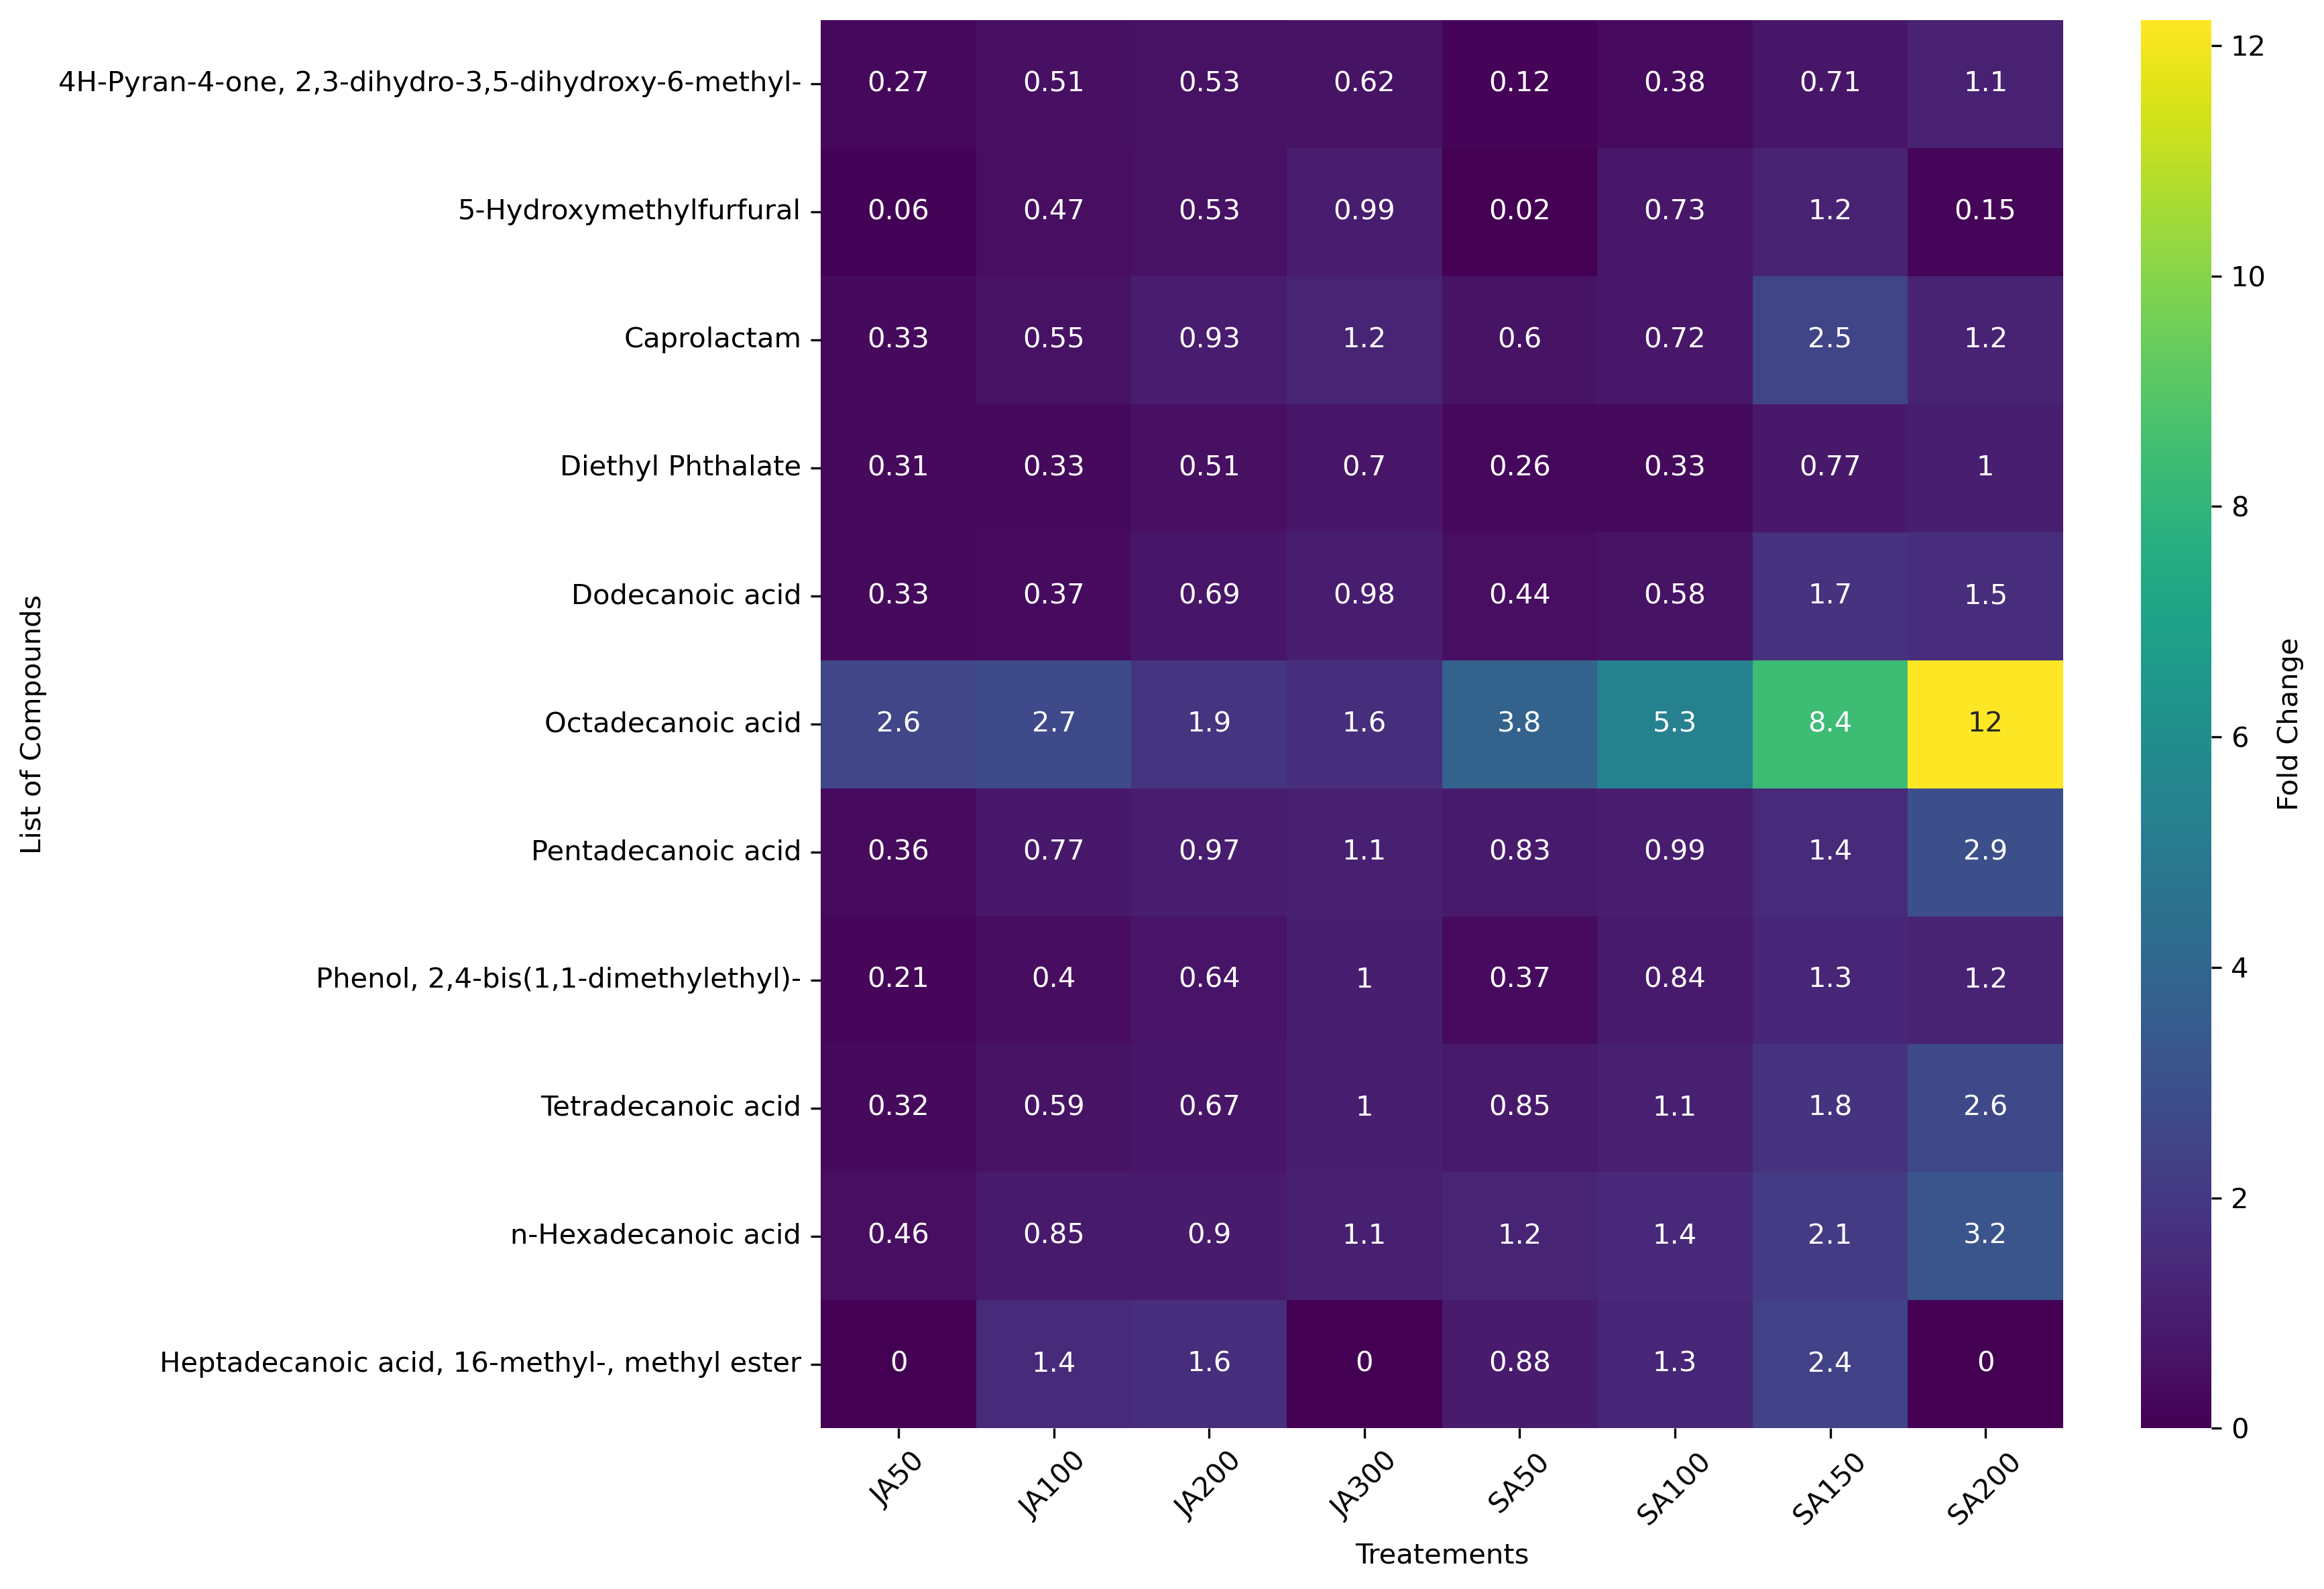

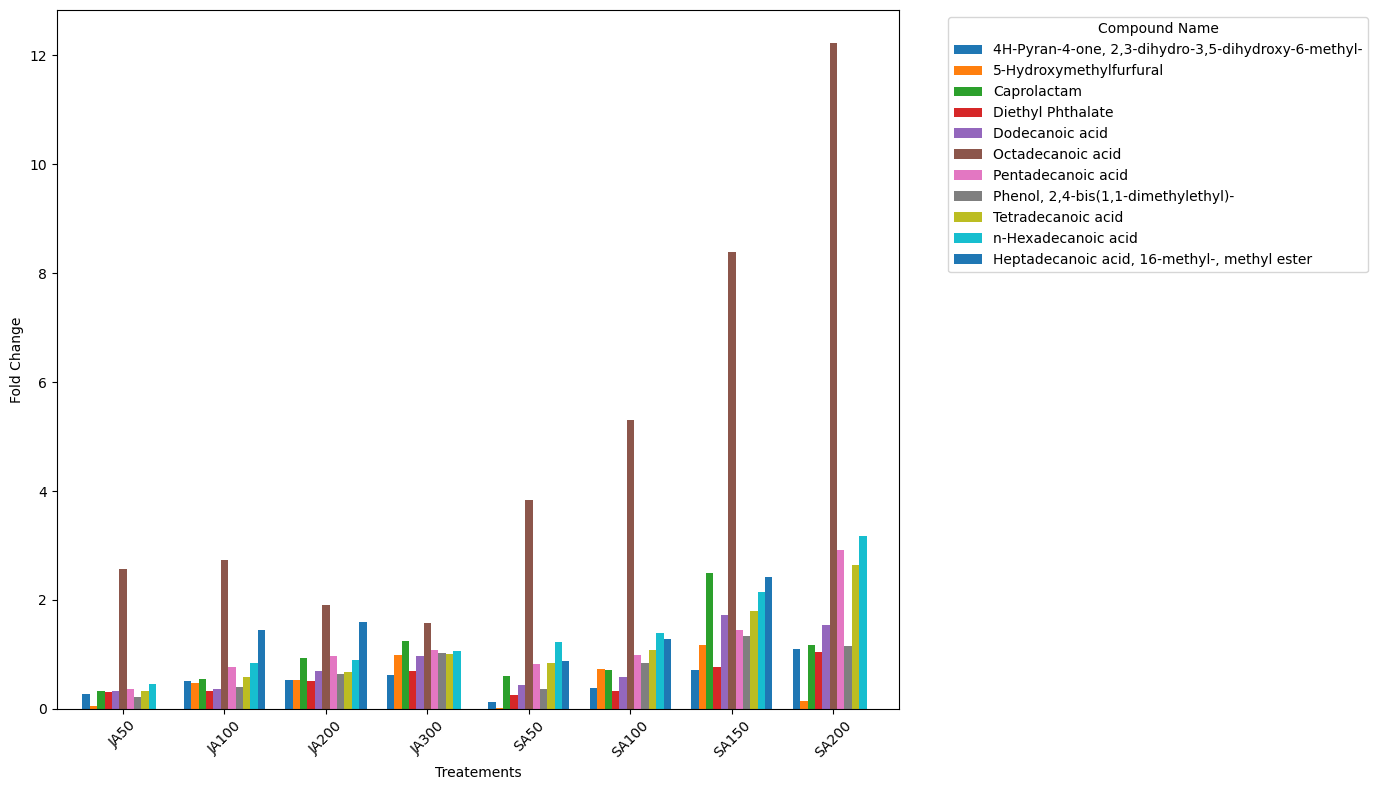

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation
data = {
    "Compound Name": [
        "4H-Pyran-4-one, 2,3-dihydro-3,5-dihydroxy-6-methyl-", "5-Hydroxymethylfurfural",
        "Caprolactam", "Diethyl Phthalate", "Dodecanoic acid", "Octadecanoic acid",
        "Pentadecanoic acid", "Phenol, 2,4-bis(1,1-dimethylethyl)-", "Tetradecanoic acid",
        "n-Hexadecanoic acid", "Heptadecanoic acid, 16-methyl-, methyl ester"
    ],
    "JA50": [0.27, 0.06, 0.33, 0.31, 0.33, 2.57, 0.36, 0.21, 0.32, 0.46, 0],
    "JA100": [0.51, 0.47, 0.55, 0.33, 0.37, 2.74, 0.77, 0.40, 0.59, 0.85, 1.44],
    "JA200": [0.53, 0.53, 0.93, 0.51, 0.69, 1.90, 0.97, 0.64, 0.67, 0.90, 1.60],
    "JA300": [0.62, 0.99, 1.24, 0.70, 0.98, 1.58, 1.08, 1.02, 1.01, 1.07, 0],
    "SA50": [0.12, 0.02, 0.60, 0.26, 0.44, 3.83, 0.83, 0.37, 0.85, 1.22, 0.88],
    "SA100": [0.38, 0.73, 0.72, 0.33, 0.58, 5.31, 0.99, 0.84, 1.08, 1.39, 1.29],
    "SA150": [0.71, 1.18, 2.49, 0.77, 1.73, 8.39, 1.45, 1.33, 1.80, 2.14, 2.43],
    "SA200": [1.10, 0.15, 1.18, 1.04, 1.54, 12.22, 2.92, 1.16, 2.64, 3.18, 0]
}

df = pd.DataFrame(data)
df.set_index("Compound Name", inplace=True)

# Heatmap
plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(df, annot=True, cmap="viridis", cbar_kws={'label': 'Fold Change'})
plt.ylabel("List of Compounds")
plt.xlabel("Treatements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar Graph
df.T.plot(kind="bar", figsize=(14, 8), width=0.8)
plt.xlabel("Treatements")
plt.ylabel("Fold Change")
plt.xticks(rotation=45)
plt.legend(title="Compound Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

# Load your data
df = pd.read_csv('your_data.csv')

# Separate features and labels
X = df.drop(columns=['Label']).values  # Replace 'Label' with the actual name of your label column if different
y = df['Label'].values  # Group labels

# Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PLS-DA
plsda = PLSRegression(n_components=2)
plsda.fit(X_scaled, pd.get_dummies(y).values)  # Use one-hot encoding for labels
X_scores = plsda.transform(X_scaled)

# Plotting PLS-DA scores
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X_scores[y == label, 0], X_scores[y == label, 1], label=label)
plt.xlabel('PLS Component 1')
plt.ylabel('PLS Component 2')
plt.title('PLS-DA')
plt.legend()
plt.grid(True)
plt.show()
